#### The dataset used can be downloaded from the following:

https://www.kaggle.com/competitions/titanic-gettingStarted


### 1) Importing Libraries, Reading the Data In, Previewing Data

In [1]:
#Add Pandas library and open the file
import pandas as pd
from pandas import Series, DataFrame

# Setup the CSV as a DataFrame
titanic_df = pd.read_csv('./data/train.csv')

# Preview the data
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### a) Checking the data Information and making note of any anomalies

The Data-Frame contents, make note that most columns have 891 non-null counts,
The column with the highest non-null counts is the 'Cabin' column with 204 non-null counts, indicating the highest missing value column

In [2]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#### 2) Analyze the Distribution Between Male and Female Passengers

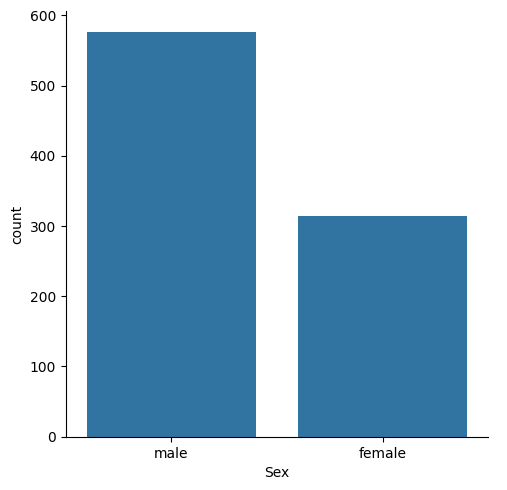

In [4]:
sns.catplot(x='Sex',data=titanic_df,kind='count')

##### * Almost twice as many Males than Females

#### a) Further Analysis of Male/Female distribution based on Passenger Class

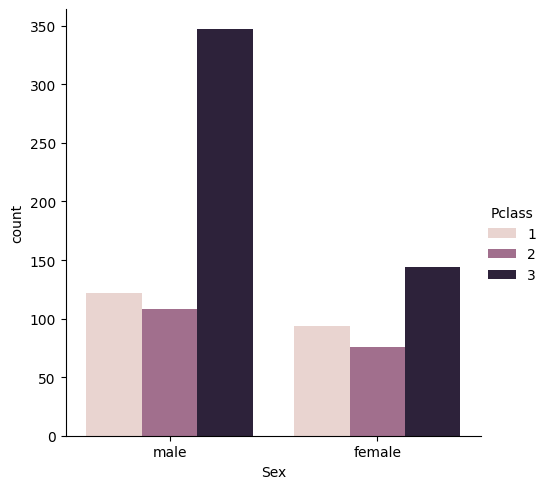

In [16]:
sns.catplot(x='Sex', data=titanic_df, hue='Pclass', kind='count')

#### c) Changed the X Axis to Ticket Class and Hue to Gender to analyze the Passenger Class by Gender Distribution

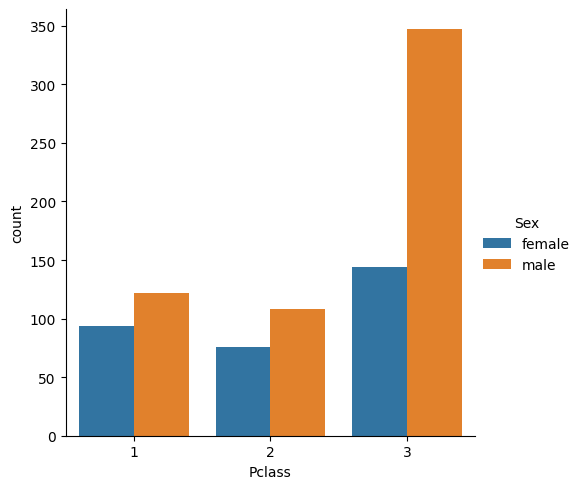

In [17]:
sns.catplot(x='Pclass', data=titanic_df, hue='Sex', kind='count')

#### 3) Further Processing of Data

In [28]:
# Function Checks a passenger to determine if it's a child or adult
# if the passengers age is less than 16 it's a child else keep gender
# the new column person is populated with the return value

def male_female_child(passenger):
    age,sex = passenger

    if age < 16:
        return 'child'
    else:
        return sex

In [177]:
#Creates a new column 'person' to the data frame, then uses Age and Sex columns, and uses the apply method to call the function
# The Age and Sex values are passed to the male_female_child function, because axis=1, it does this for each row.

titanic_df['person'] = titanic_df[['Age','Sex']].apply(male_female_child,axis=1)

In [178]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person,Alone,Survivor,cabin_level,Female_w_family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,With Family,no,NaN,Alone
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,With Family,yes,C,Female_w_family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,Alone,yes,NaN,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,With Family,yes,C,Female_w_family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male,Alone,no,NaN,Alone


#### a) Plot the Male, Female or Child vs Ticket Class
Review the distribution

Text(0.5, 1.0, 'Distribution of Male, Female, and Child by Passenger Class')

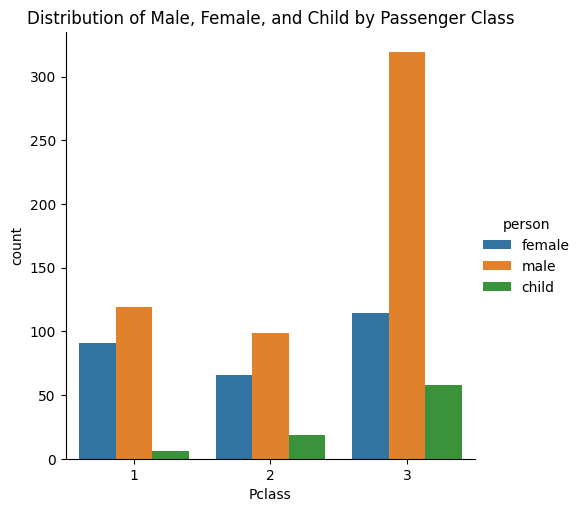

In [180]:
sns.catplot(x='Pclass',data=titanic_df,hue='person', kind='count')
plt.title('Distribution of Male, Female, and Child by Passenger Class')

#### b) Generate a Histogram based on Age category with a Bin Size of 70

<Axes: >

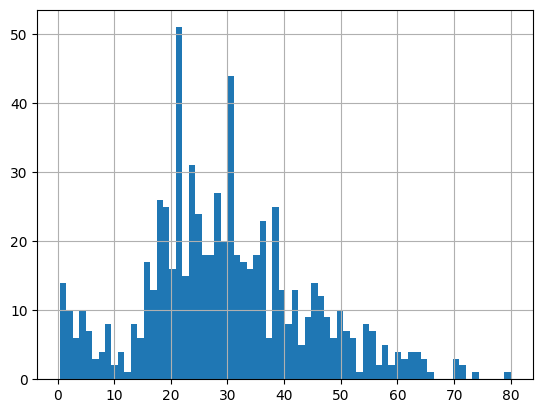

In [25]:
titanic_df['Age'].hist(bins=70)

In [26]:
titanic_df['Age'].mean()

np.float64(29.69911764705882)

In [27]:
titanic_df['person'].value_counts()

person
male      537
female    271
child      83
Name: count, dtype: int64

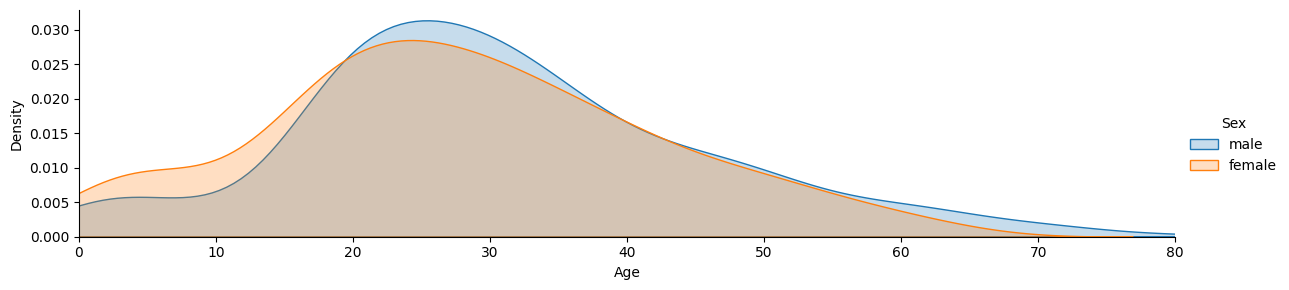

In [40]:
fig = sns.FacetGrid(titanic_df, hue= 'Sex',aspect= 4)
fig.map(sns.kdeplot,'Age',fill= True)

oldest = titanic_df['Age'].max()

fig.set(xlim =(0,oldest))
fig.add_legend()

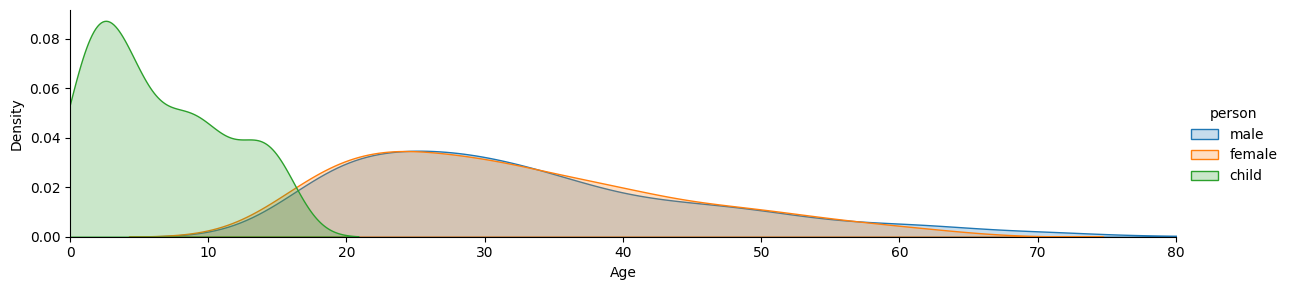

In [41]:
fig = sns.FacetGrid(titanic_df, hue='person',aspect=4)
fig.map(sns.kdeplot,'Age',fill=True)

oldest = titanic_df['Age'].max()

fig.set(xlim=(0,oldest))
fig.add_legend()

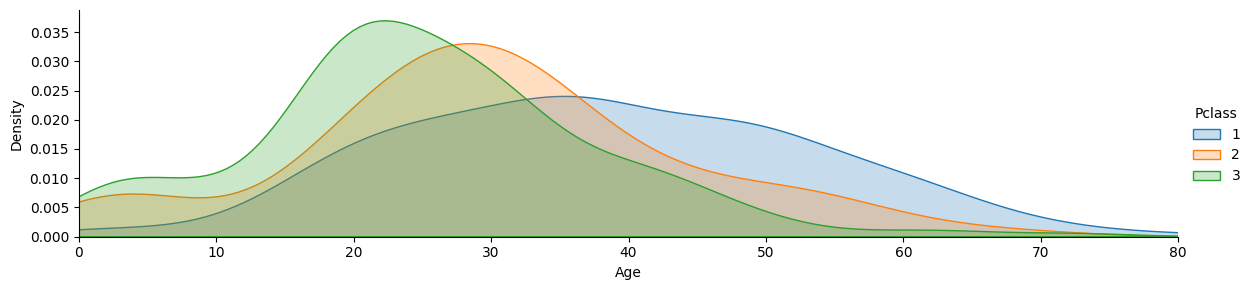

In [42]:
fig = sns.FacetGrid(titanic_df, hue='Pclass',aspect=4)
fig.map(sns.kdeplot,'Age',fill=True)

oldest = titanic_df['Age'].max()

fig.set(xlim=(0,oldest))
fig.add_legend()

In [43]:
deck = titanic_df['Cabin'].dropna()

In [44]:
deck.head()

1      C85
3     C123
6      E46
10      G6
11    C103
Name: Cabin, dtype: object

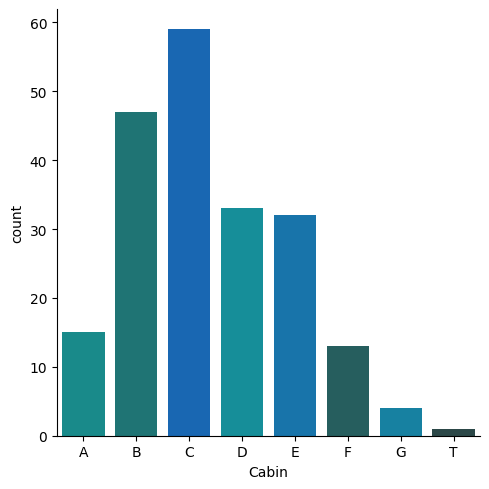

In [175]:
levels = []

for level in deck:
    levels.append(level[0])

cabin_df = DataFrame(levels)
cabin_df.columns = ['Cabin']
sns.catplot(x='Cabin', data=cabin_df,hue='Cabin', order=['A','B','C','D','E','F','G','T'], palette='winter_d',kind='count')

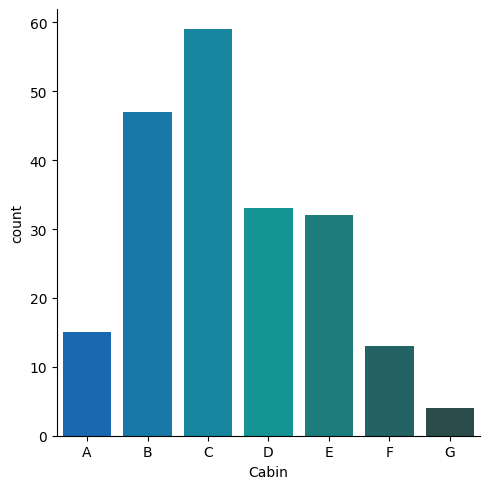

In [171]:
cabin_df = cabin_df[cabin_df.Cabin != 'T']

sns.catplot(x='Cabin',
            data=cabin_df.sort_values('Cabin'),
            hue='Cabin',
            palette='winter_d',
            kind='count',
            order=sorted(cabin_df['Cabin'].unique()))

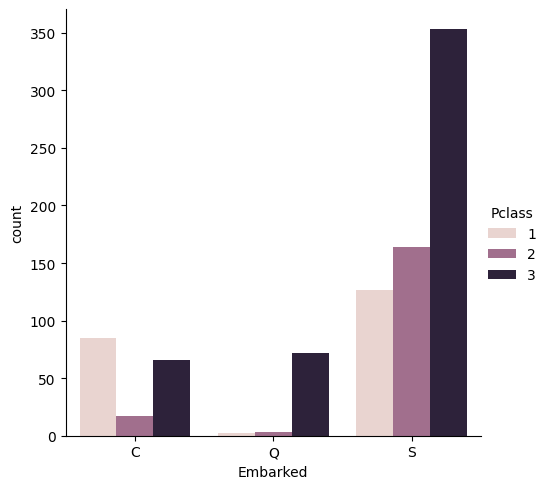

In [60]:
sns.catplot(x='Embarked',data=titanic_df,hue='Pclass',order=['C','Q','S'],kind='count')

#### 4) Ananlysis of the Data
###### Who was alone and who was with family?

In [61]:
titanic_df['Alone'] = titanic_df.SibSp + titanic_df.Parch

In [62]:
titanic_df['Alone']

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: Alone, Length: 891, dtype: int64

In [173]:
# Define Alone based on SibSp + Parch
titanic_df['Alone'] = np.where(
    (titanic_df['SibSp'] + titanic_df['Parch']) > 0,
    'With Family',
    'Alone'
)



In [165]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person,Alone,Survivor,cabin_level,Female_w_family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,With Family,no,NaN,Alone
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,With Family,yes,C,Female_w_family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,Alone,yes,NaN,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,With Family,yes,C,Female_w_family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male,Alone,no,NaN,Alone


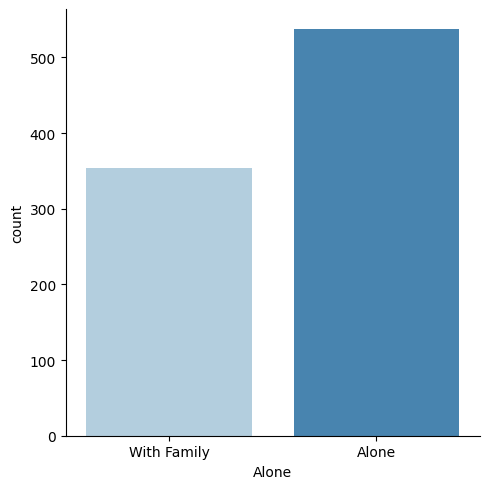

In [166]:
sns.catplot(x='Alone',data=titanic_df,hue='Alone',palette='Blues',kind='count')

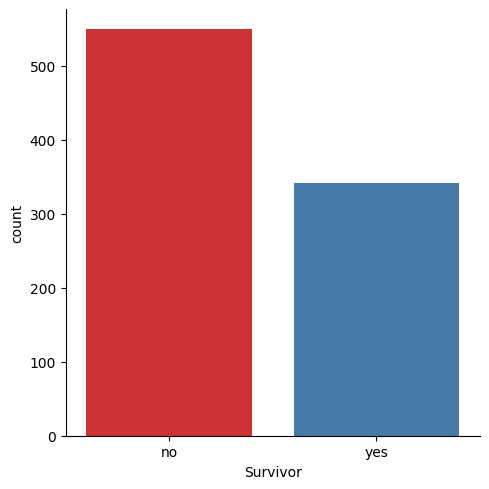

In [167]:
titanic_df['Survivor']= titanic_df.Survived.map({0:'no',1:'yes'})
sns.catplot(x='Survivor', data=titanic_df, hue='Survivor',palette='Set1', kind='count')                        

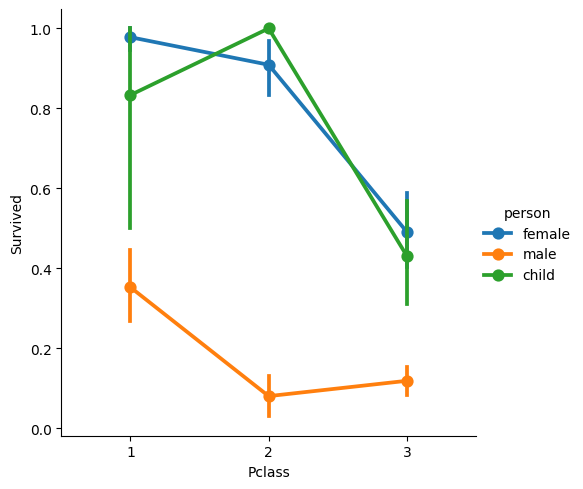

In [169]:
sns.catplot(x='Pclass', y='Survived', hue='person', data=titanic_df, kind='point')


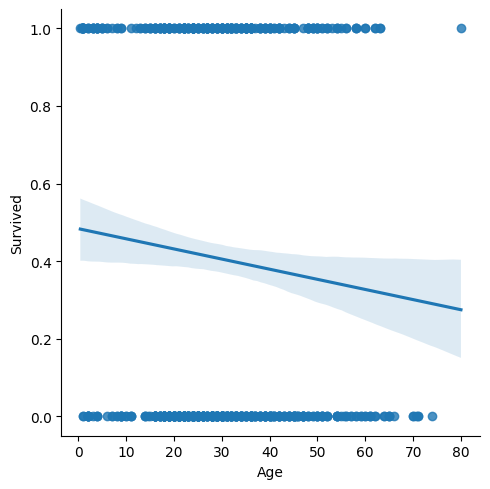

In [81]:
sns.lmplot(x='Age',y='Survived',data=titanic_df)

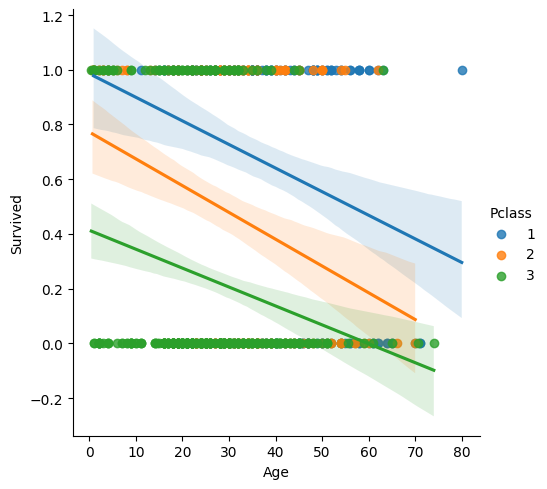

In [82]:
sns.lmplot(x='Age',y='Survived',hue='Pclass',data=titanic_df)

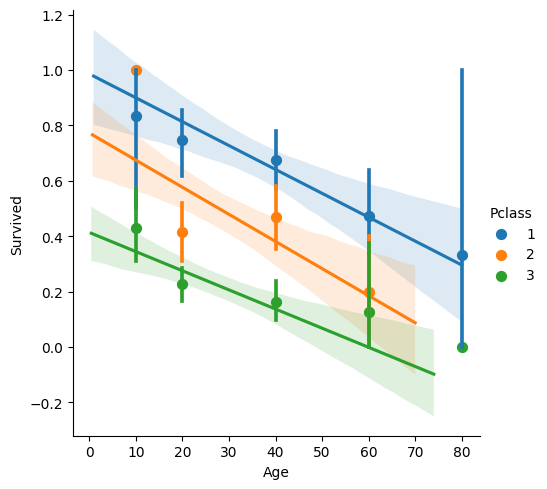

In [84]:
generations = [10,20,40,60,80]

sns.lmplot(x='Age',y='Survived', hue='Pclass', data = titanic_df, x_bins=generations)

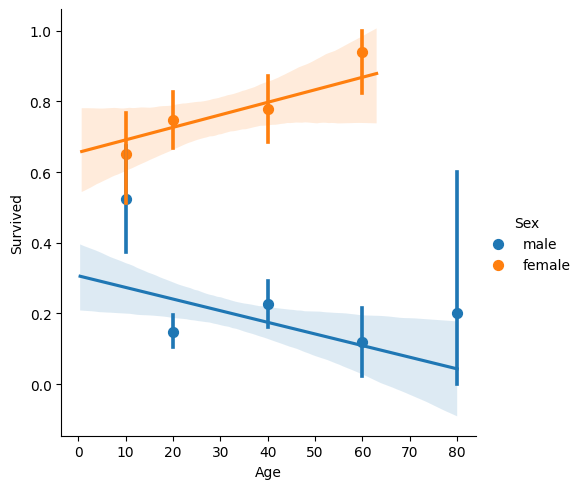

In [110]:
sns.lmplot(x='Age',y='Survived', hue='Sex', data = titanic_df, x_bins=generations)

In [97]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person,Alone,Survivor,cabin_level
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,With Family,no,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,With Family,yes,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,Alone,yes,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,With Family,yes,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male,Alone,no,NaN


In [96]:
# Add cabin level column and grab the first character of the string
titanic_df['cabin_level']=titanic_df['Cabin'].str[0]

Text(0.5, 0, 'Cabin Level')

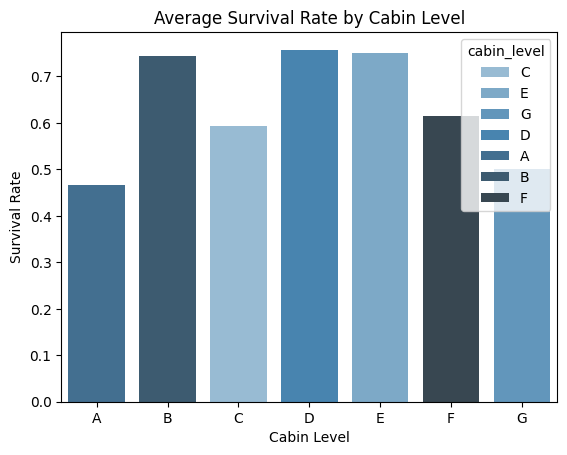

In [155]:
titanic_df_filtered = titanic_df[titanic_df['cabin_level'] != 'T']

sns.barplot(
    x='cabin_level',
    y='Survived',
    hue='cabin_level',
    data=titanic_df_filtered,
    order=['A','B','C','D','E','F','G'],
    errorbar=None,
    palette='Blues_d'
)
plt.title('Average Survival Rate by Cabin Level')
plt.ylabel('Survival Rate')
plt.xlabel('Cabin Level')

Text(0.5, 0, 'Cabin Level')

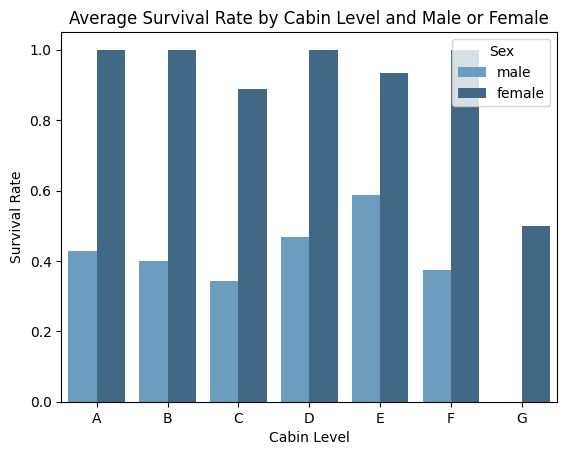

In [152]:
sns.barplot(
    x='cabin_level',
    y='Survived',
    hue='Sex',
    data=titanic_df[titanic_df['cabin_level'] != 'T'],
    order=['A','B','C','D','E','F','G'],
    palette='Blues_d',
    errorbar=None
)

plt.title('Average Survival Rate by Cabin Level and Male or Female')
plt.ylabel('Survival Rate')
plt.xlabel('Cabin Level')

Text(0.5, 0, 'Cabin Level')

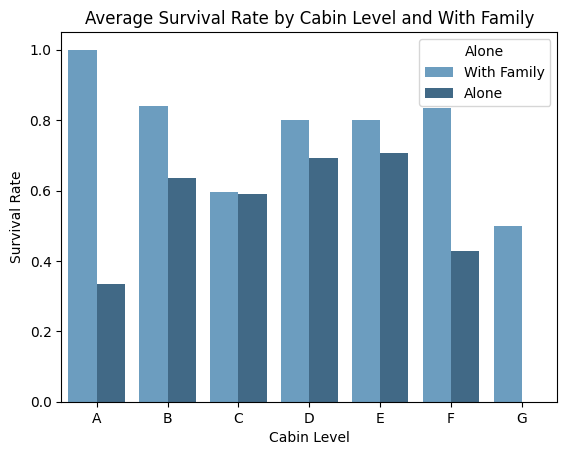

In [151]:
sns.barplot(
    x='cabin_level',
    y='Survived',
    hue='Alone',
    data=titanic_df[titanic_df['cabin_level'] != 'T'],
    order=['A','B','C','D','E','F','G'],
    palette='Blues_d',
    errorbar=None
)

plt.title('Average Survival Rate by Cabin Level and With Family')
plt.ylabel('Survival Rate')
plt.xlabel('Cabin Level')

In [147]:
titanic_df['Female_w_family']=np.where(
    (titanic_df['Sex']=='female') & (titanic_df['Alone'] == 'With Family'),
    'Female_w_family',
    'Alone')

Text(0.5, 0, 'Cabin Level')

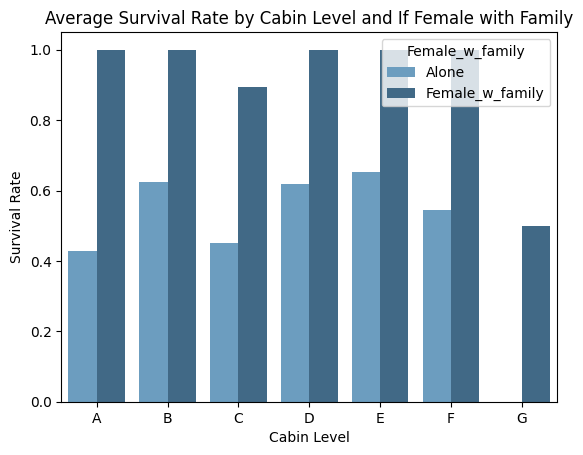

In [150]:
sns.barplot(
    x='cabin_level',
    y='Survived',
    hue='Female_w_family',
    data=titanic_df[titanic_df['cabin_level'] != 'T'],
    order=['A','B','C','D','E','F','G'],
    palette='Blues_d',
    errorbar=None
)

plt.title('Average Survival Rate by Cabin Level and If Female with Family')
plt.ylabel('Survival Rate')
plt.xlabel('Cabin Level')

Deck level doesn't play much of a role in determining the survival rate, but it does seem that 1st class tickets at lower levels have a higher probablity of survival (Female and traveling with family).  The cabin data had the highest amount of null values in the set. The plot shows a large delta in survival based on sex and traveling with family.

<Axes: xlabel='Alone', ylabel='Survived'>

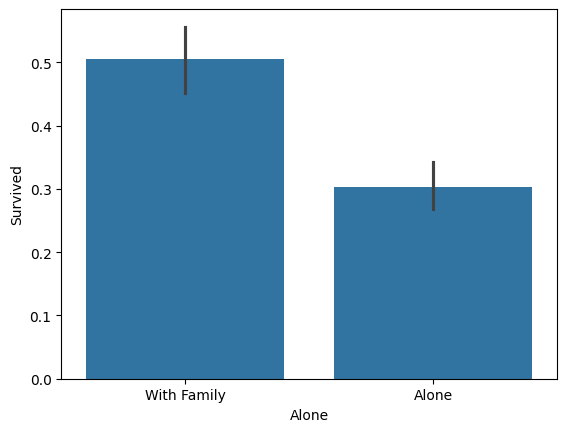

In [136]:
#Determining if there is a higher chance of survival if with family or alone
sns.barplot(x='Alone',y='Survived', data=titanic_df)

<Axes: xlabel='Female_w_family', ylabel='Survived'>

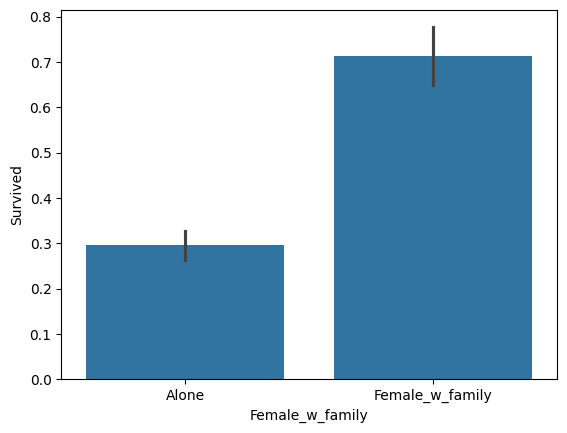

In [172]:
sns.barplot(x='Female_w_family',y='Survived', data=titanic_df)

If the passenger was traveling with family, they had a better probablity of surviving the crash, likely due to the Women and Children first rule, thus securing a spot on a lifeboat.  There's a 40% higher probability that a Female traveling with family will be assigned a lifeboat.